# 04 · SHAP interpretability (Session 4)

Explaining the **app-only XGBoost winner** with **TreeSHAP**, on a random 10k
sample of the 2016 test set. The computation lives in `src/shap_analysis.py`;
this notebook summarizes it.

The goal isn't another accuracy number — it's a **sanity check**: are the model's
drivers economically sensible, and is it free of proxy / leakage surprises? For
a credit model that faces model-risk review, being able to answer that is as
important as the AUC.


In [1]:
from pathlib import Path
import pandas as pd
from IPython.display import Image

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
REP = ROOT / "reports"
imp = pd.read_csv(REP / "shap_importance.csv")

## Global importance — which features drive risk

In [2]:
imp.head(15).reset_index(drop=True)

,feature,mean_abs_shap
0,num__term,0.452662
1,num__installment,0.254931
2,num__fico_range_high,0.160469
3,num__dti,0.158080
4,num__acc_open_past_24mths,0.144963
5,num__annual_inc,0.144910
6,num__inq_last_6mths,0.080153
7,num__mo_sin_old_rev_tl_op,0.070773
8,num__funded_amnt_inv,0.068363
9,num__num_tl_op_past_12m,0.066587


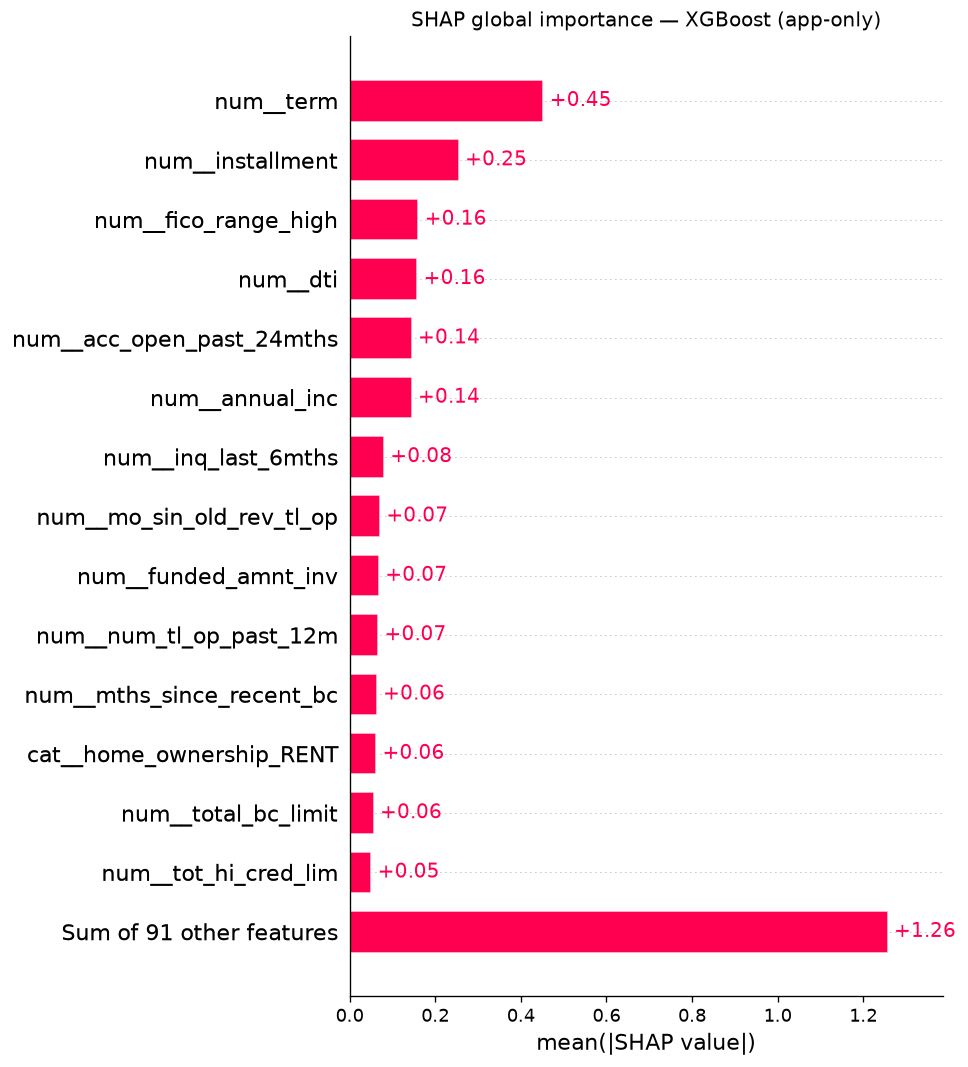

In [3]:
Image(filename=str(REP / "shap_bar.png"))

## Direction of each effect (beeswarm)

Colour = feature value (red high, blue low); x-position = push on default risk.

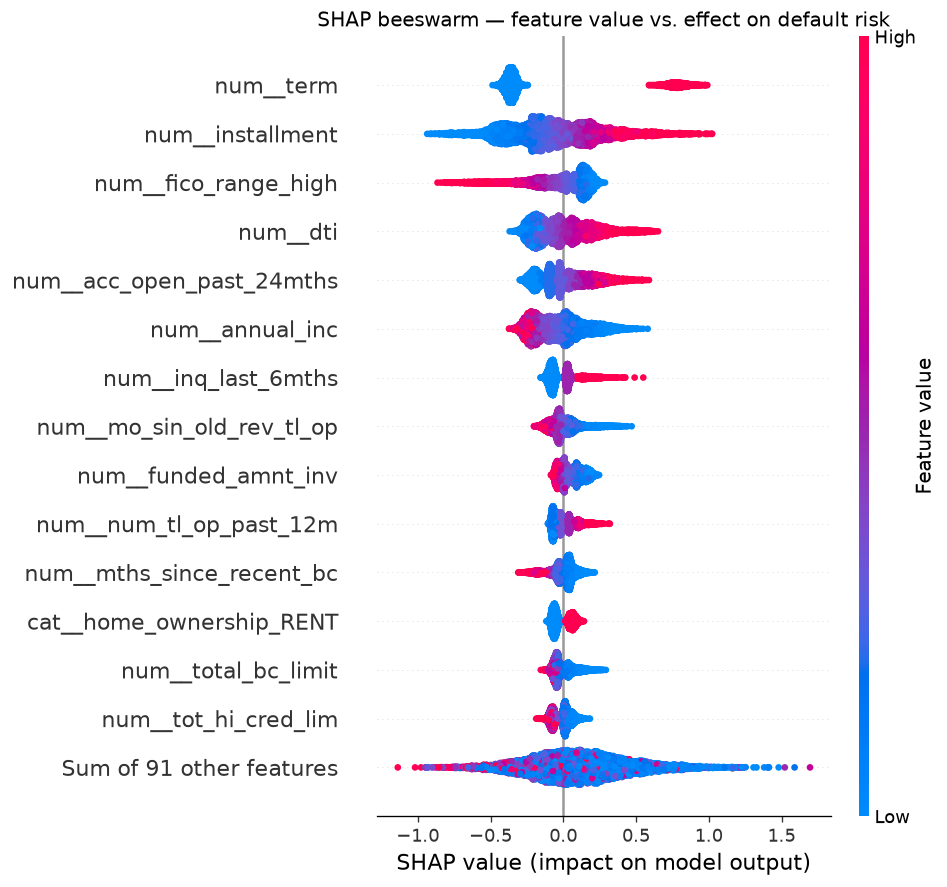

In [4]:
Image(filename=str(REP / "shap_beeswarm.png"))

Every direction is what a credit analyst would expect:

| Feature | Effect on default risk |
|---|---|
| `term` (top driver) | 60-month → **up**, 36-month → down |
| `installment`, `dti` | bigger payment / higher debt burden → **up** |
| `fico_range_high` | higher score → **down** |
| `annual_inc` | higher income → **down** |
| `acc_open_past_24mths`, `inq_last_6mths`, `num_tl_op_past_12m` | more recent credit-seeking → **up** |
| `mo_sin_old_rev_tl_op` | longer credit history → **down** |
| `home_ownership_RENT` | renters → **up** vs. owners |


## Local explanations — "why this loan?"

The single highest- and lowest-risk loans in the sample, decomposed into each
feature's contribution (log-odds) from the base rate to the final score.

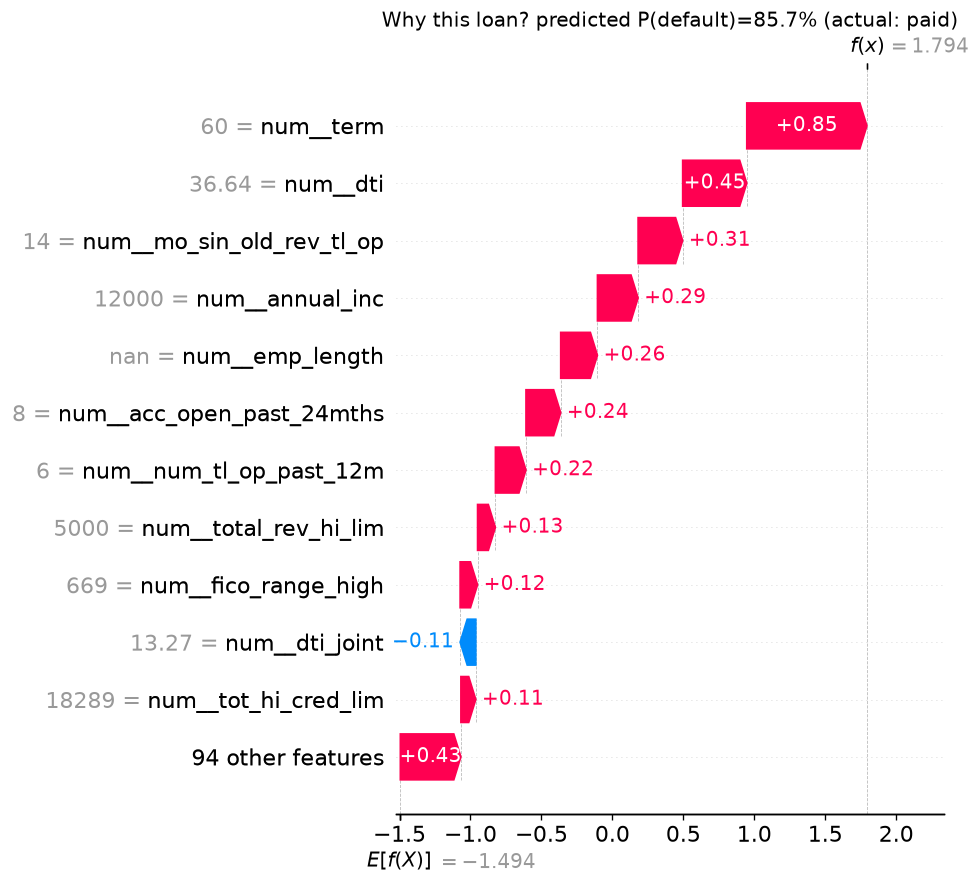

In [5]:
Image(filename=str(REP / "shap_waterfall_highrisk.png"))

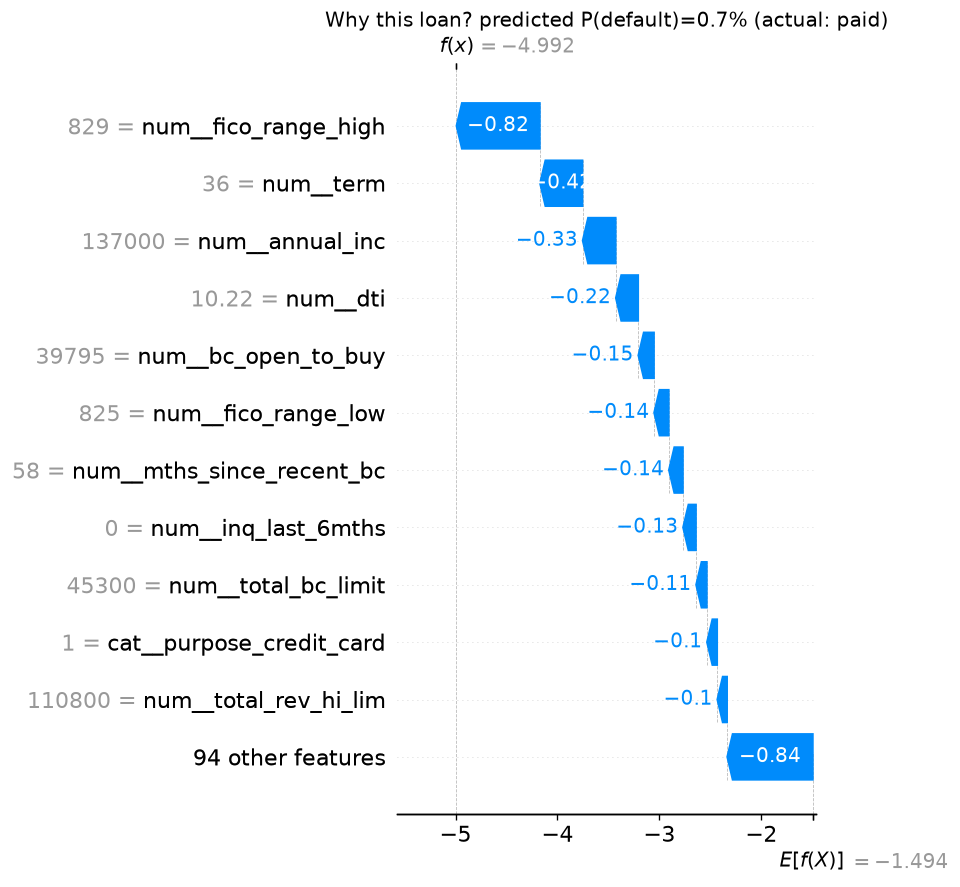

In [6]:
Image(filename=str(REP / "shap_waterfall_lowrisk.png"))

The highest-risk loan (PD 85.7%) is driven by a 60-month term, DTI of 37, a
short 14-month credit history, \$12k income, and heavy recent credit-seeking
(8 new accounts in 24 months) — a coherent, defensible story. (It *actually
paid off*: even an 86% PD leaves ~14% who repay.)

## Why this is a strong result

1. **No leakage snuck in.** Not one post-origination feature appears anywhere
   in the ranking — the Session-1 column triage held all the way through.
2. **No proxy red flags.** No geography (ZIP/state were dropped for fair
   lending), and no single feature dominates implausibly. `term` leads, but at a
   reasonable magnitude — the model earns its ~0.72 AUC across many features
   rather than riding a hidden shortcut. This is exactly what a model-validation
   review (e.g. SR 11-7) checks for.
3. **Decisions are explainable.** Each score decomposes into intelligible
   contributions you could hand to a declined applicant.

**Next — Session 5:** a Streamlit app (application → calibrated PD →
approve/decline at a chosen cutoff, with the SHAP explanation) plus the written
recommendation.